# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

In [ ]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

#plt.style.use('seaborn')

In [ ]:
#Isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

# Carregar Dados

In [ ]:
df_reviews = pd.read_csv('imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [ ]:
df_reviews

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47326,tt0068398,tvEpisode,Étude in Black,Étude in Black,1972,\N,97,0,"Crime,Drama,Mystery",7.7,2254,This is another of my favorite Columbos. It sp...,10,pos,1,test,6038
47327,tt0223503,tvMovie,Îhatôbu gensô: KENjI no haru,Îhatôbu gensô: KENjI no haru,1996,\N,55,0,"Animation,Biography,Drama",7.3,278,Talk about being boring! I got this expecting ...,4,neg,0,test,989
47328,tt0223503,tvMovie,Îhatôbu gensô: KENjI no haru,Îhatôbu gensô: KENjI no haru,1996,\N,55,0,"Animation,Biography,Drama",7.3,278,"I never thought I'd say this about a biopic, b...",8,pos,1,test,4163
47329,tt0223503,tvMovie,Îhatôbu gensô: KENjI no haru,Îhatôbu gensô: KENjI no haru,1996,\N,55,0,"Animation,Biography,Drama",7.3,278,Spirit and Chaos is an artistic biopic of Miya...,9,pos,1,test,4164


In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [ ]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


# AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

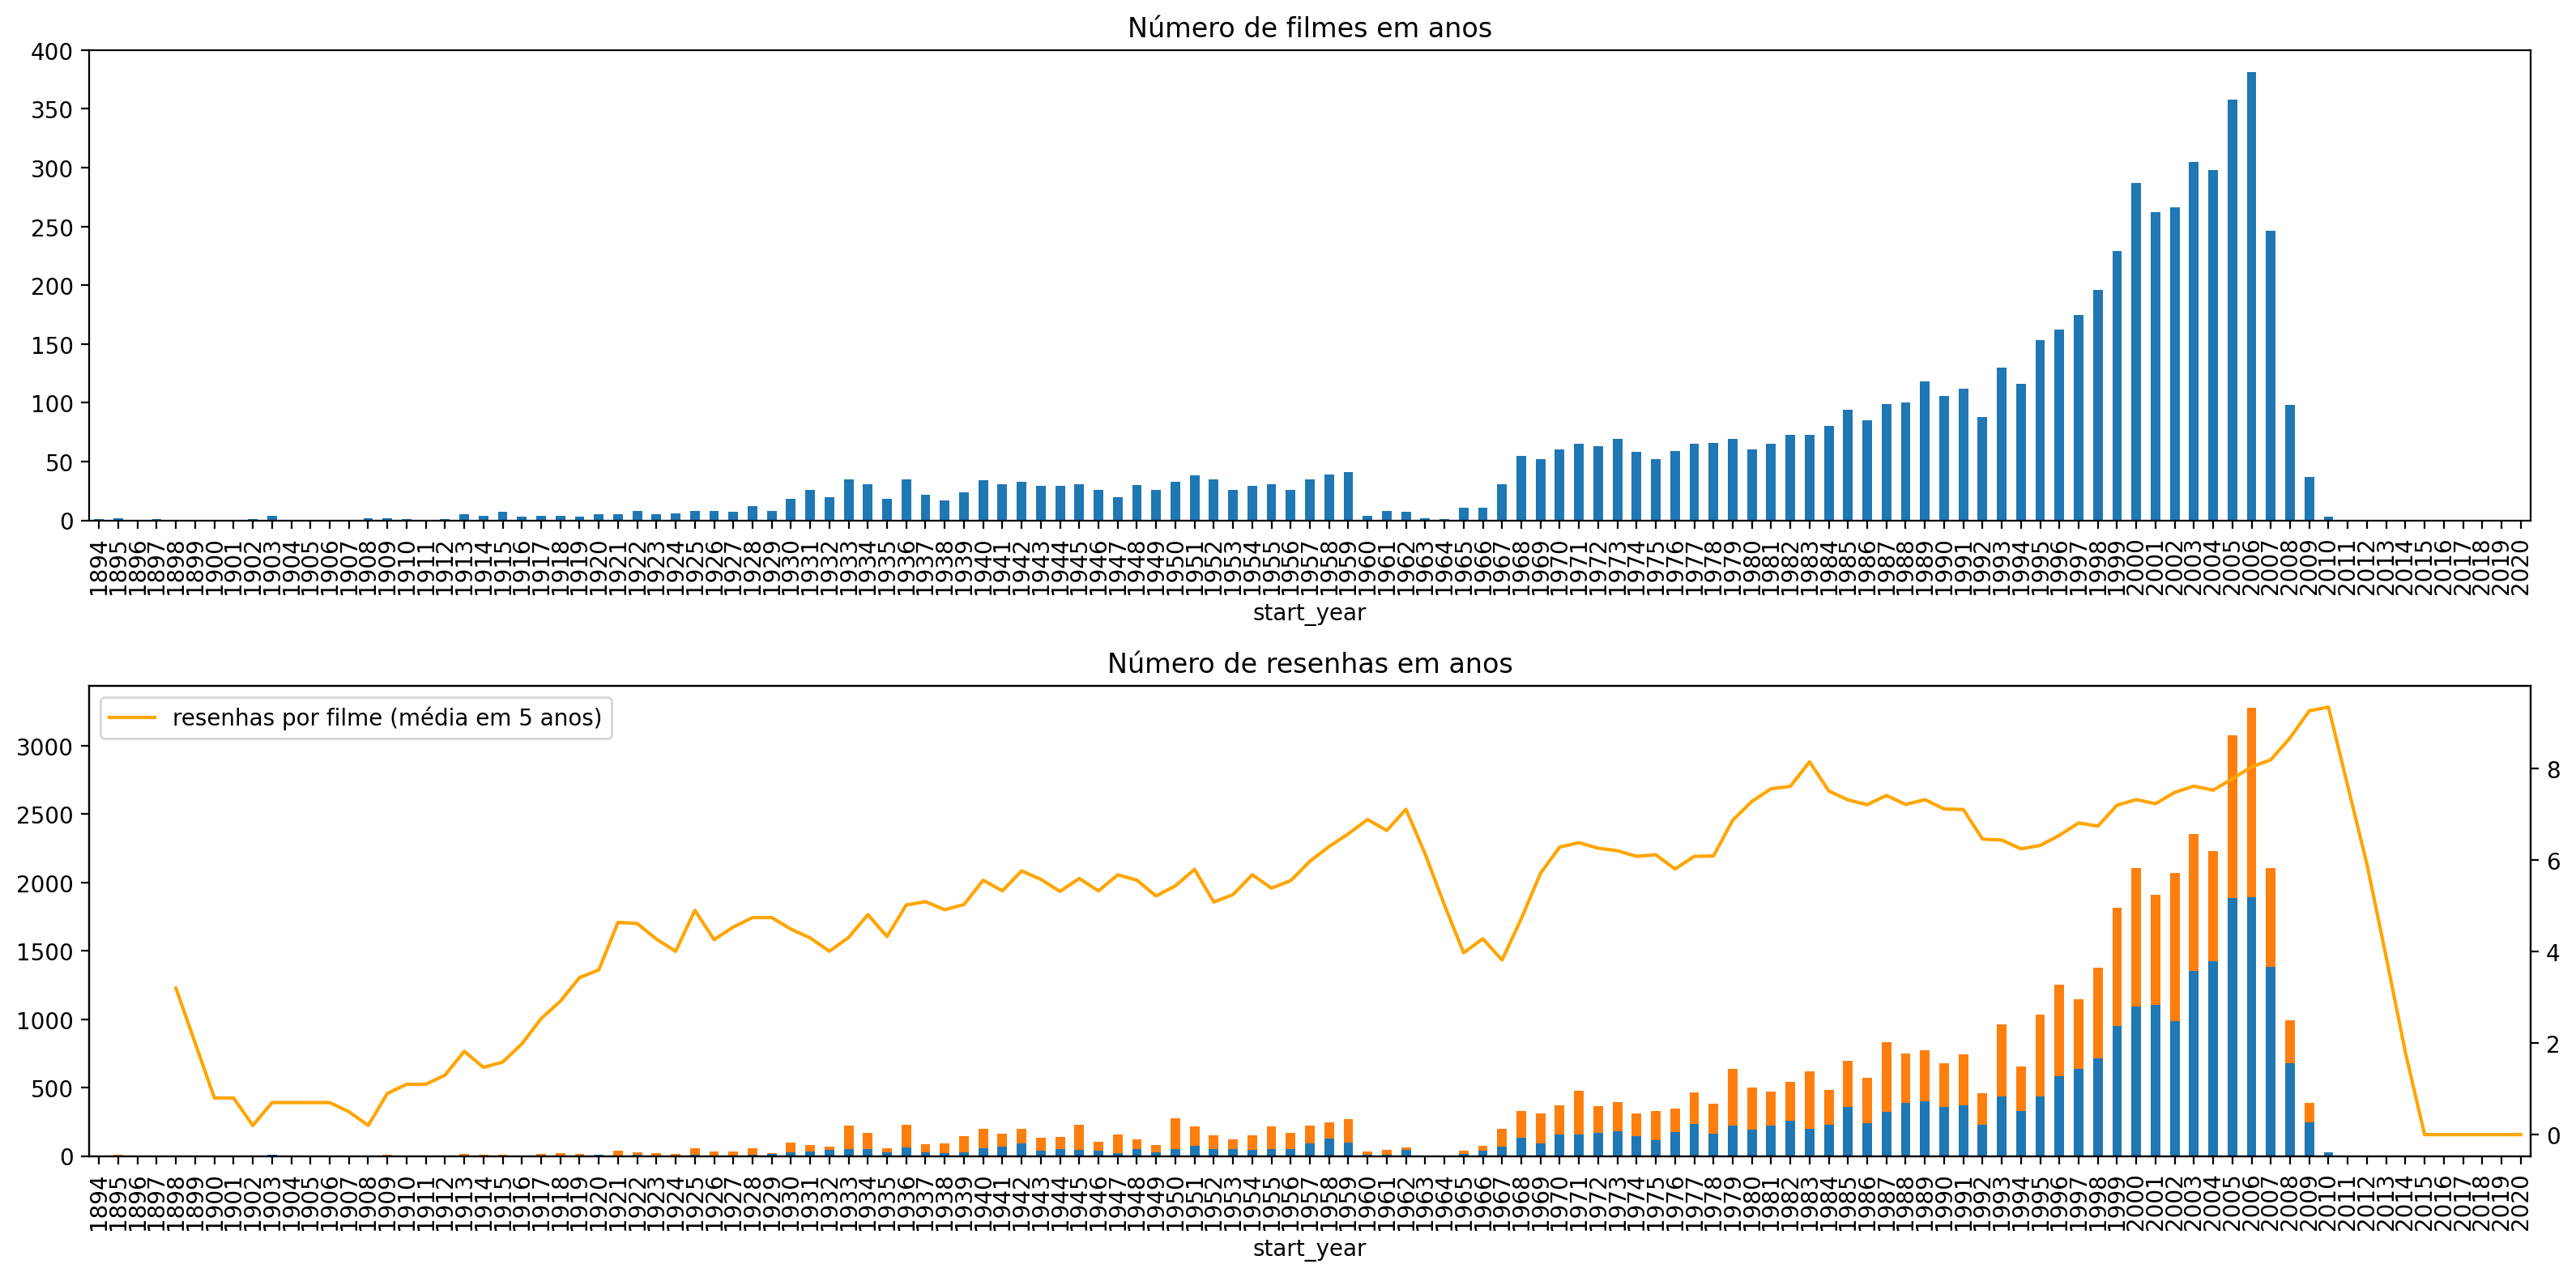

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Os dados sugerem uma indústria cinematográfica em expansão em termos de produção de filmes, com um pico recente.
Contudo, enquanto o volume total de resenhas acompanhou essa expansão, a intensidade de resenhas por filme individualmente parece ter diminuído nos anos mais recentes, levantando questões sobre a visibilidade ou o engajamento sustentado por cada novo lançamento em um cenário de maior oferta.

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

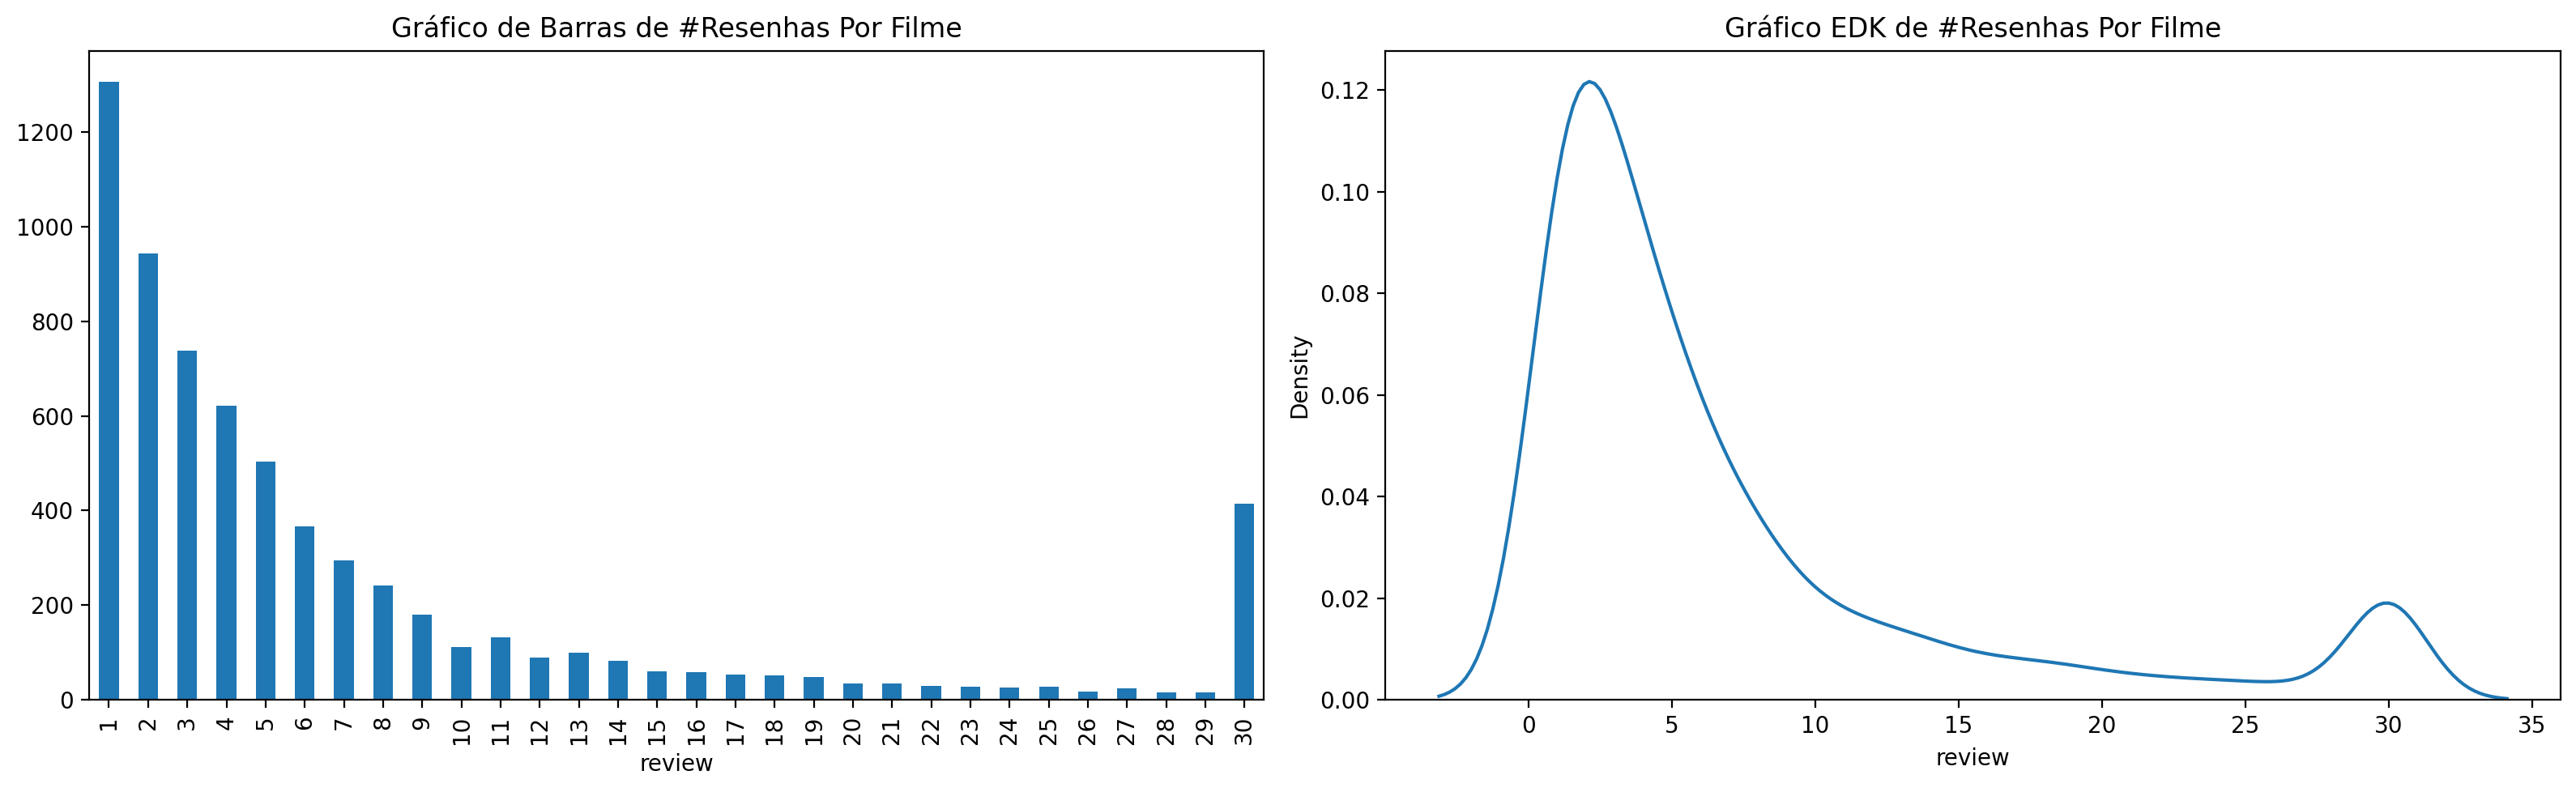

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

# Conclusão

A esmagadora maioria dos filmes recebe poucas resenhas, com a maior concentração tendo apenas 1 a 5 resenhas.
Isso sugere que apenas uma pequena parcela dos filmes consegue captar uma atenção significativa da audiência para gerar um grande volume de resenhas. Há uma clara "lei de potência" ou distribuição de cauda longa, onde poucos "blockbusters" ou filmes muito populares dominam o volume de interações e comentários, enquanto a vasta maioria dos filmes permanece com pouca visibilidade em termos de engajamento de resenhas.

In [ ]:
df_reviews['pos'].value_counts()

,count
pos,
0,23715
1,23616


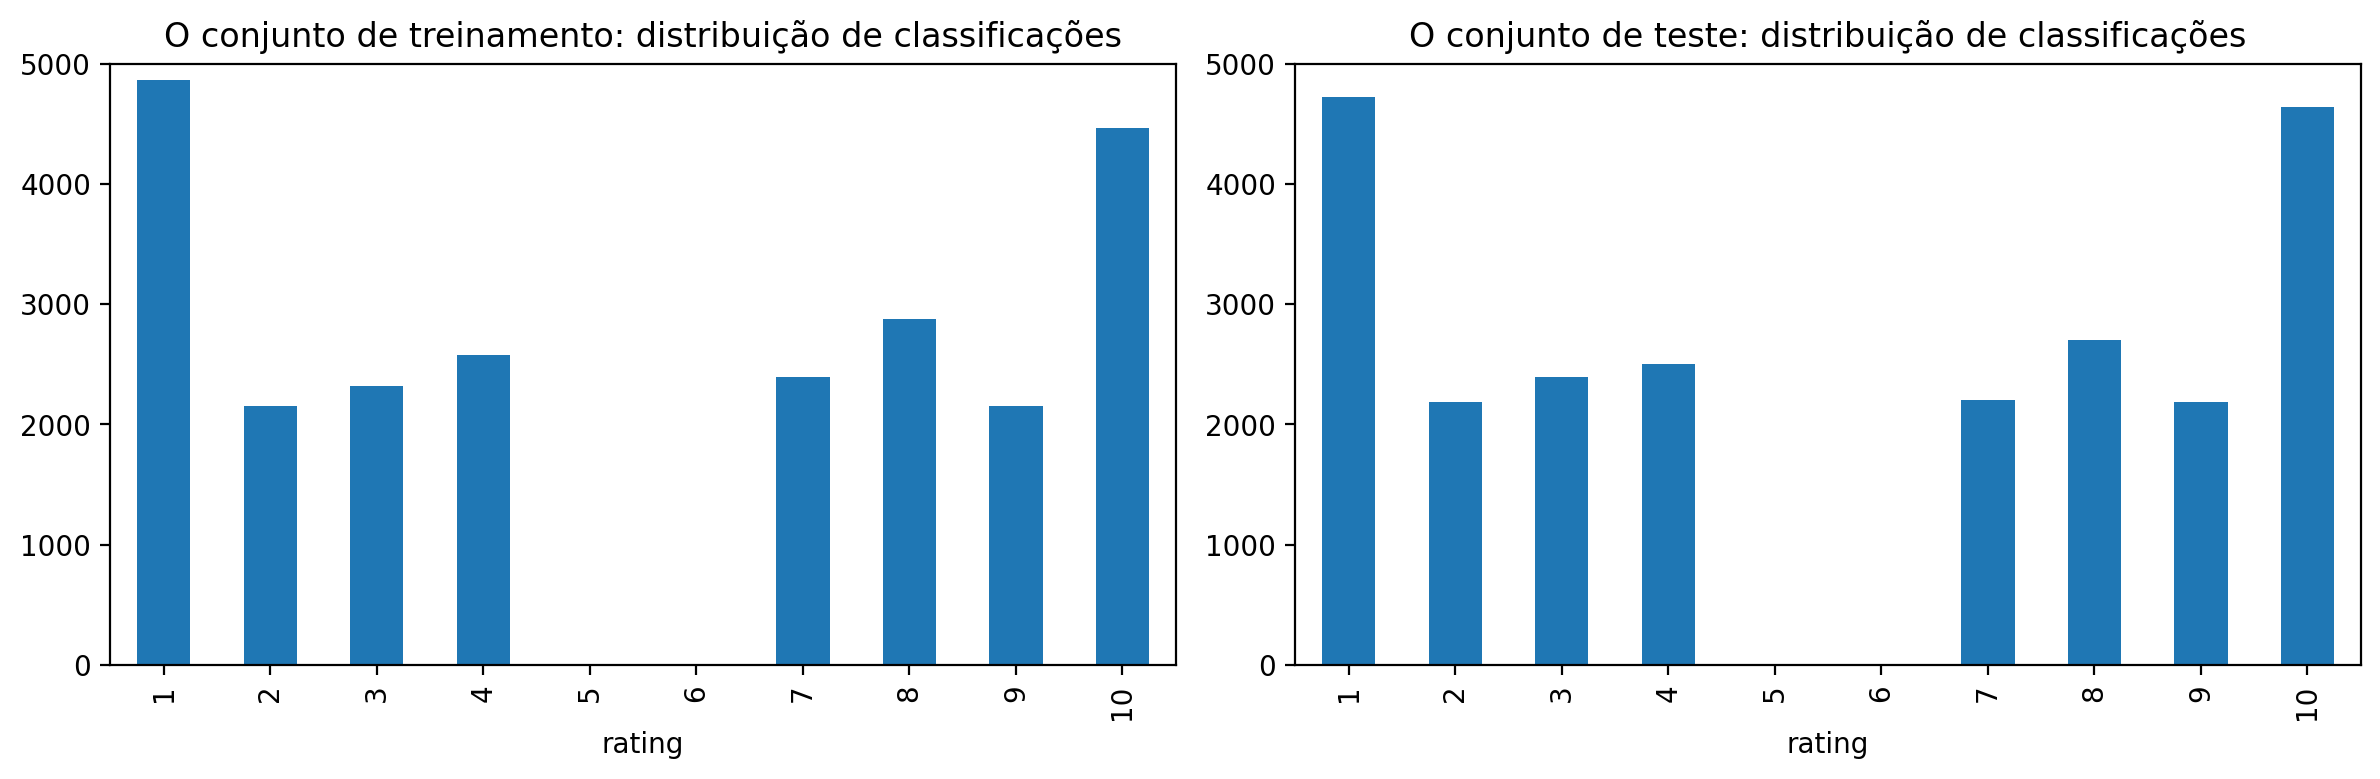

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

# Conclusão

Os conjuntos de treinamento e teste possuem uma distribuição de classificações bastante consistente e representativa.
A principal característica dessa distribuição é a polarização das avaliações, com uma grande concentração nas notas extremas (1 e 10). Isso implica que a maioria dos usuários tende a expressar opiniões muito negativas ou muito positivas.
Além disso, a ausência ou raridade da classificação 6 é um ponto crucial que pode influenciar modelos de machine learning, pois eles terão pouquíssimos (ou nenhum) exemplos para aprender sobre essa categoria específica.
Modelos de recomendação ou classificação precisarão lidar com essa polarização e a "lacuna" na classificação 6.

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/tmp/ipython-input-16-1483671763.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipython-input-16-1483671763.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
/tmp/ipython-input-16-1483671763.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipython-input-16-1483671763.py:31: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please u

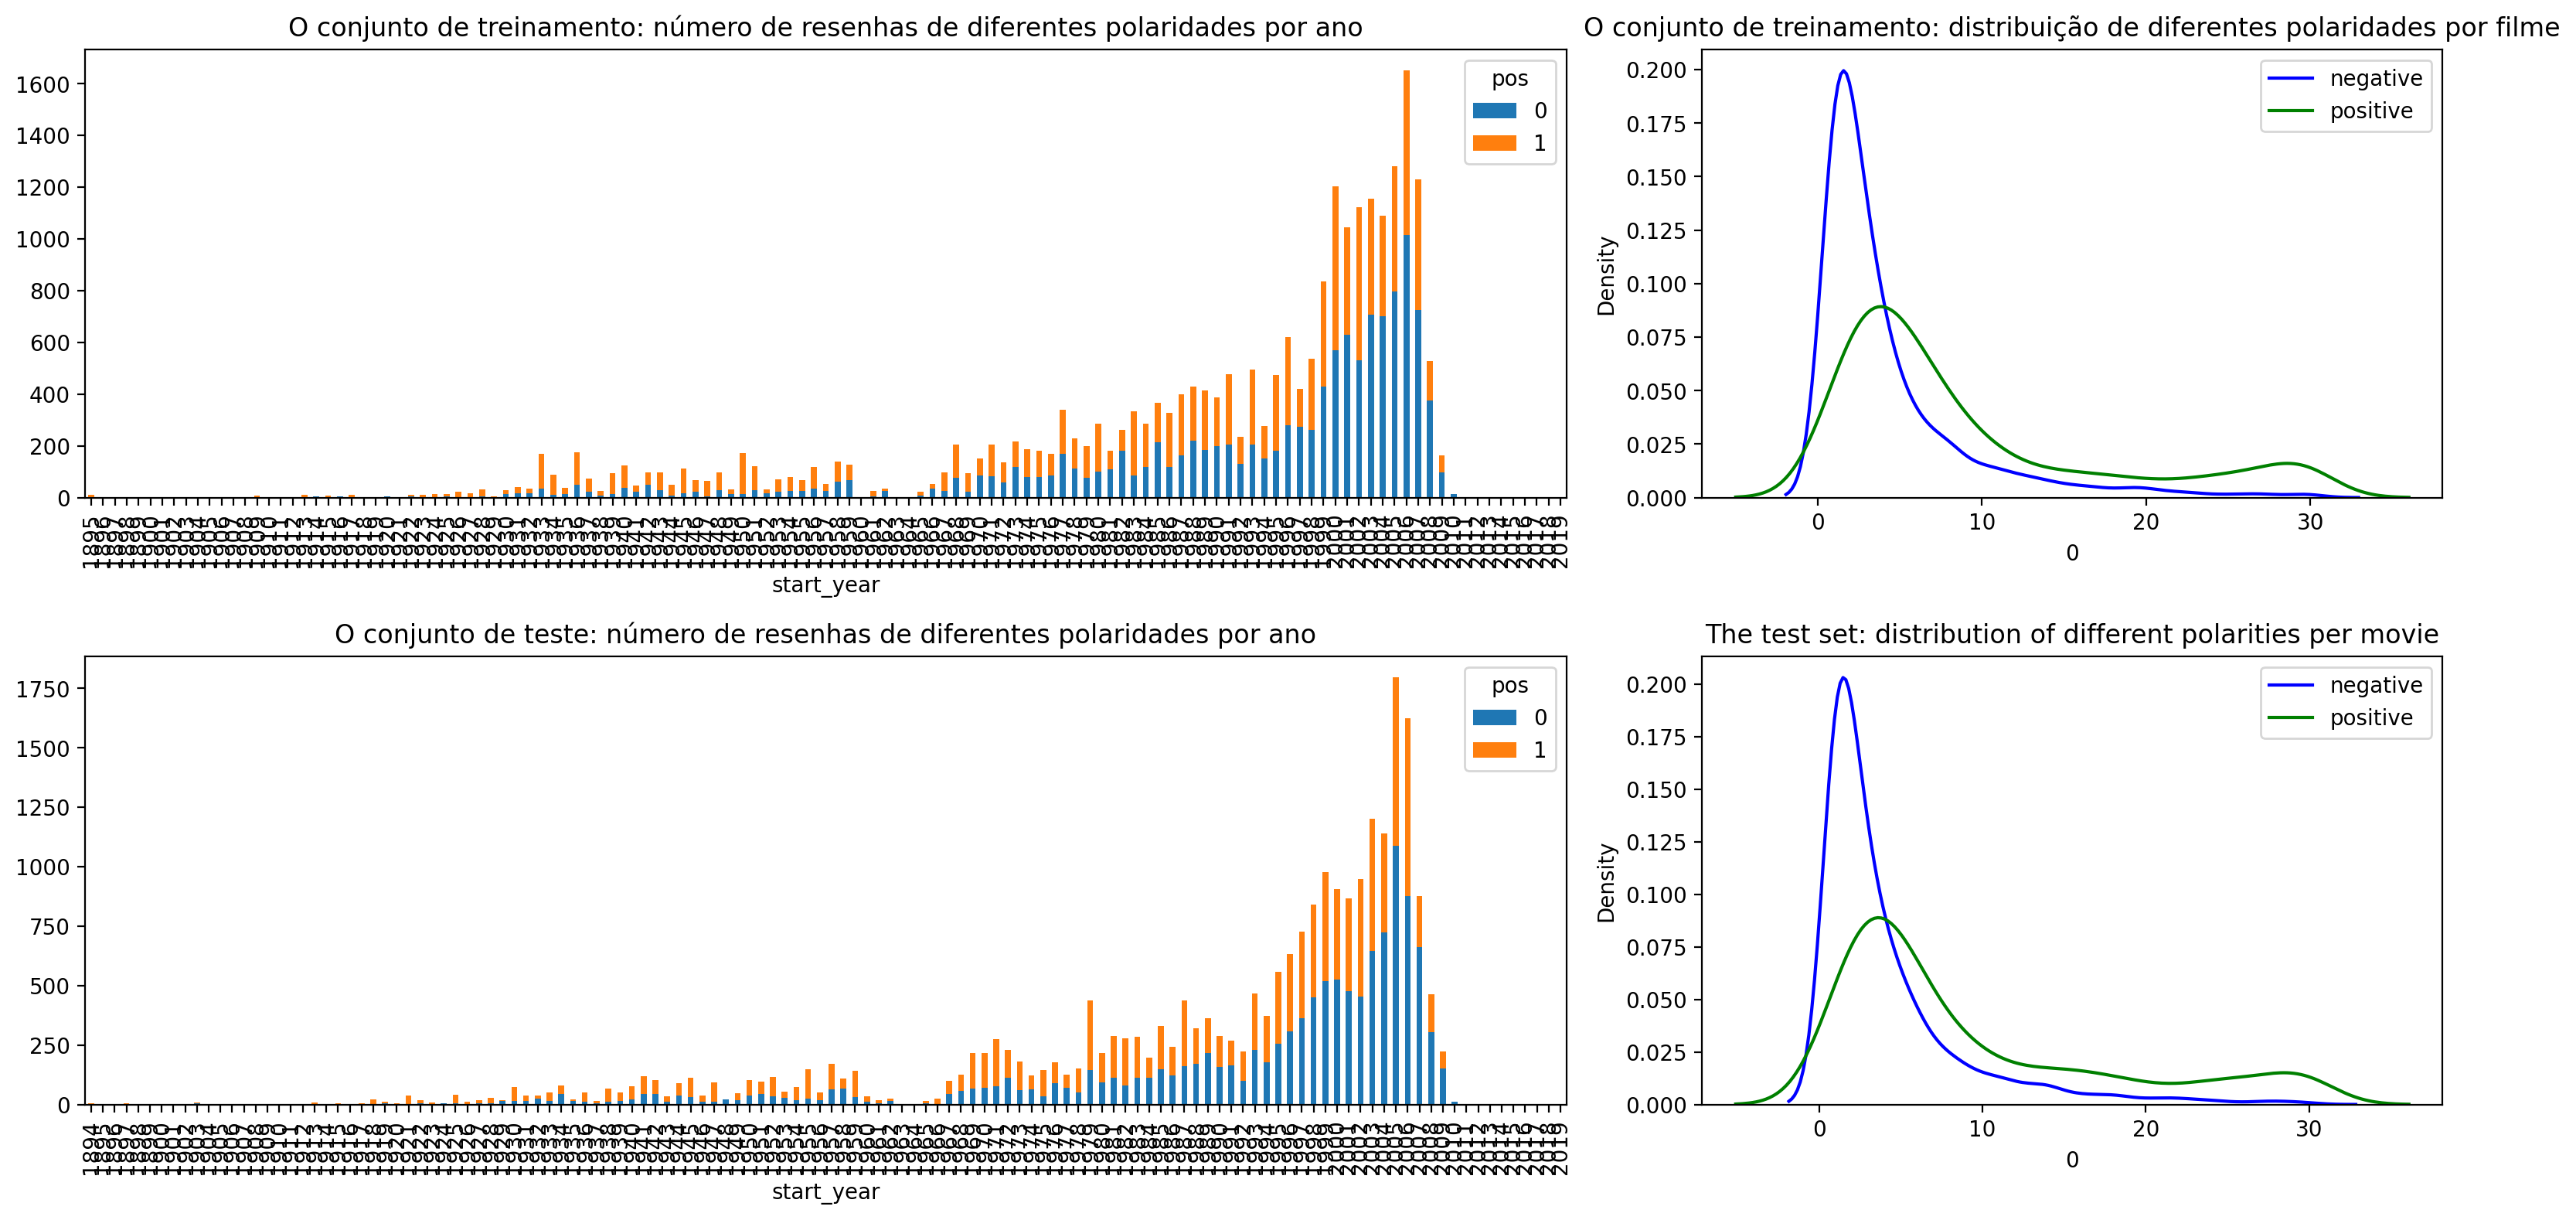

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

Observa-se um aumento significativo no número total de resenhas ao longo dos anos (eixo 'start_year'), com um crescimento particularmente acentuado a partir de meados dos anos 2000 em diante, atingindo picos por volta de 2015-2017. Para ambos os conjuntos (treinamento e teste), a quantidade de resenhas positivas (representadas em laranja/código '1') é consistentemente maior do que a de resenhas negativas (representadas em azul/código '0') em praticamente todos os anos. Isso sugere uma tendência geral de mais avaliações positivas para os filmes, ou talvez um viés na coleta dos dados.

As distribuições de densidade (gráficos à direita) mostram a polaridade das resenhas por filme. Tanto no conjunto de treinamento quanto no de teste, as resenhas negativas (azul) tendem a ter uma distribuição mais concentrada em valores menores (próximos de 0), indicando que, quando um filme recebe resenhas negativas, elas podem ser mais esparsas ou concentradas em poucos filmes com muitas resenhas negativas. Por outro lado, as resenhas positivas (verde) mostram uma distribuição mais "espalhada" ou com uma cauda mais longa, sugerindo que muitos filmes recebem um número considerável de resenhas positivas, ou que a variabilidade no número de resenhas positivas por filme é maior. No entanto, é importante notar que a escala do eixo '0' nos gráficos de densidade é a mesma (0 a 35), o que nos permite comparar diretamente as formas das distribuições. Ambas as distribuições (negativa e positiva) decaem rapidamente após os primeiros valores, indicando que a maioria dos filmes não acumula um número extremamente alto de resenhas.
Em suma, os dados demonstram um crescimento exponencial na quantidade de resenhas de filmes ao longo do tempo, com uma predominância de resenhas positivas. As características das distribuições de polaridade são robustas e semelhantes entre os conjuntos de treinamento e teste, o que é um bom indicativo da consistência dos dados.

# Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [ ]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps

        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'Curva ROC')

        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return

# Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [ ]:
#Normalização de resenhas
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
df_reviews['review_norm'] = df_reviews['review'].progress_apply(lambda x: x.lower().strip())
df_reviews['review_norm'] = df_reviews['review_norm'].progress_apply(lambda x: ' '.join(x.split()))
df_reviews['review_norm'] = df_reviews['review_norm'].progress_apply(lambda x: x.replace(' ', ' '))

  0%|          | 0/47331 [00:00<?, ?it/s]

  0%|          | 0/47331 [00:00<?, ?it/s]

  0%|          | 0/47331 [00:00<?, ?it/s]

# Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [ ]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


# Trabalhando com modelos

# Modelo 0 - Constante

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


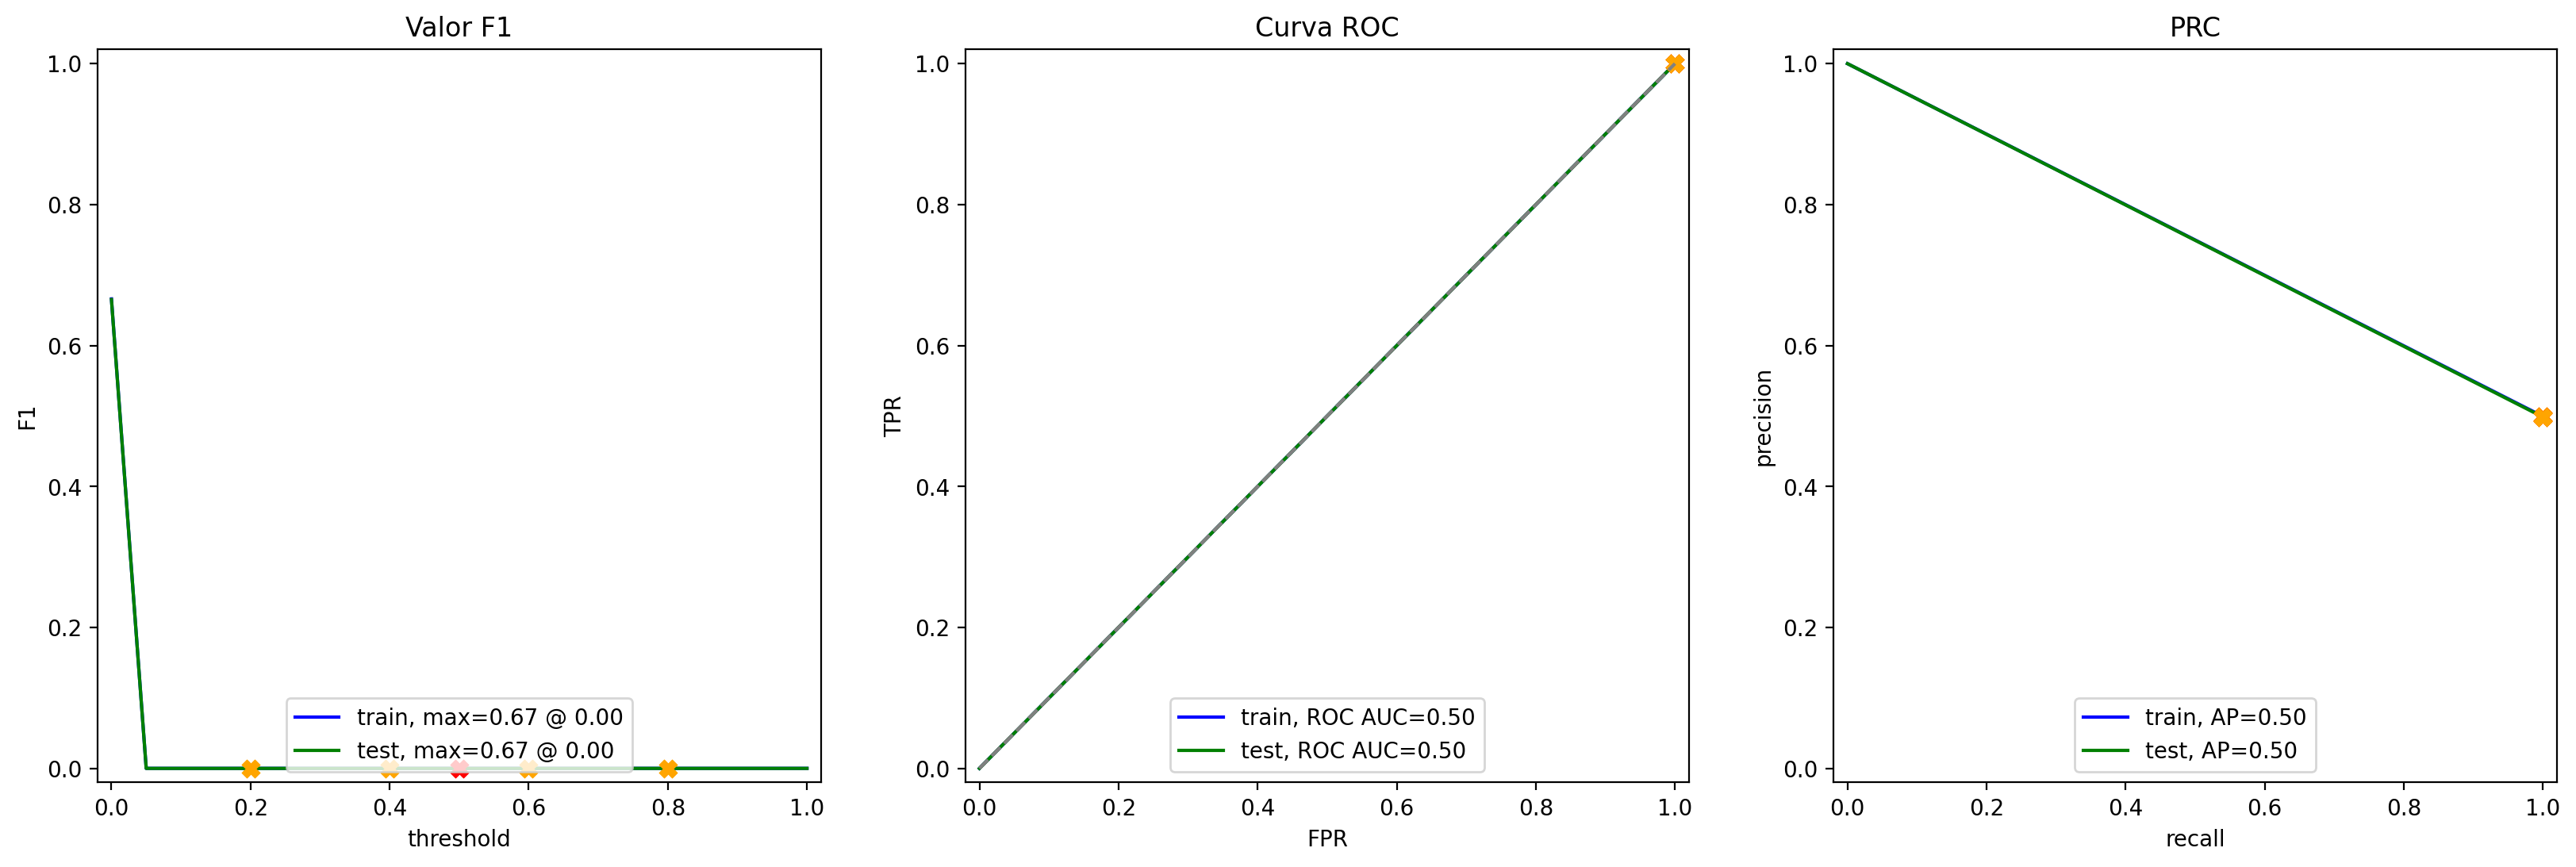

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(df_reviews_train['review_norm'], train_target)
dummy_model.predict(df_reviews_test['review_norm'])
evaluate_model(dummy_model, df_reviews_train['review_norm'], train_target, df_reviews_test['review_norm'], test_target)

Os resultados de todos os gráficos são consistentes em apontar para um modelo com desempenho muito fraco. O F1-score quase nulo para a maioria dos thresholds, a AUC de 0.50 (indicando classificação aleatória) e o baixo Average Precision (0.50) sugerem que o modelo não aprendeu padrões significativos nos dados e não é capaz de diferenciar efetivamente as classes.

# Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF - IDF

In [ ]:
import nltk

nltk.download('stopwords')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


convergence after 19 epochs took 1 seconds
          train  test
Accuracy   0.93  0.89
F1         0.93  0.89
APS        0.98  0.96
ROC AUC    0.98  0.96


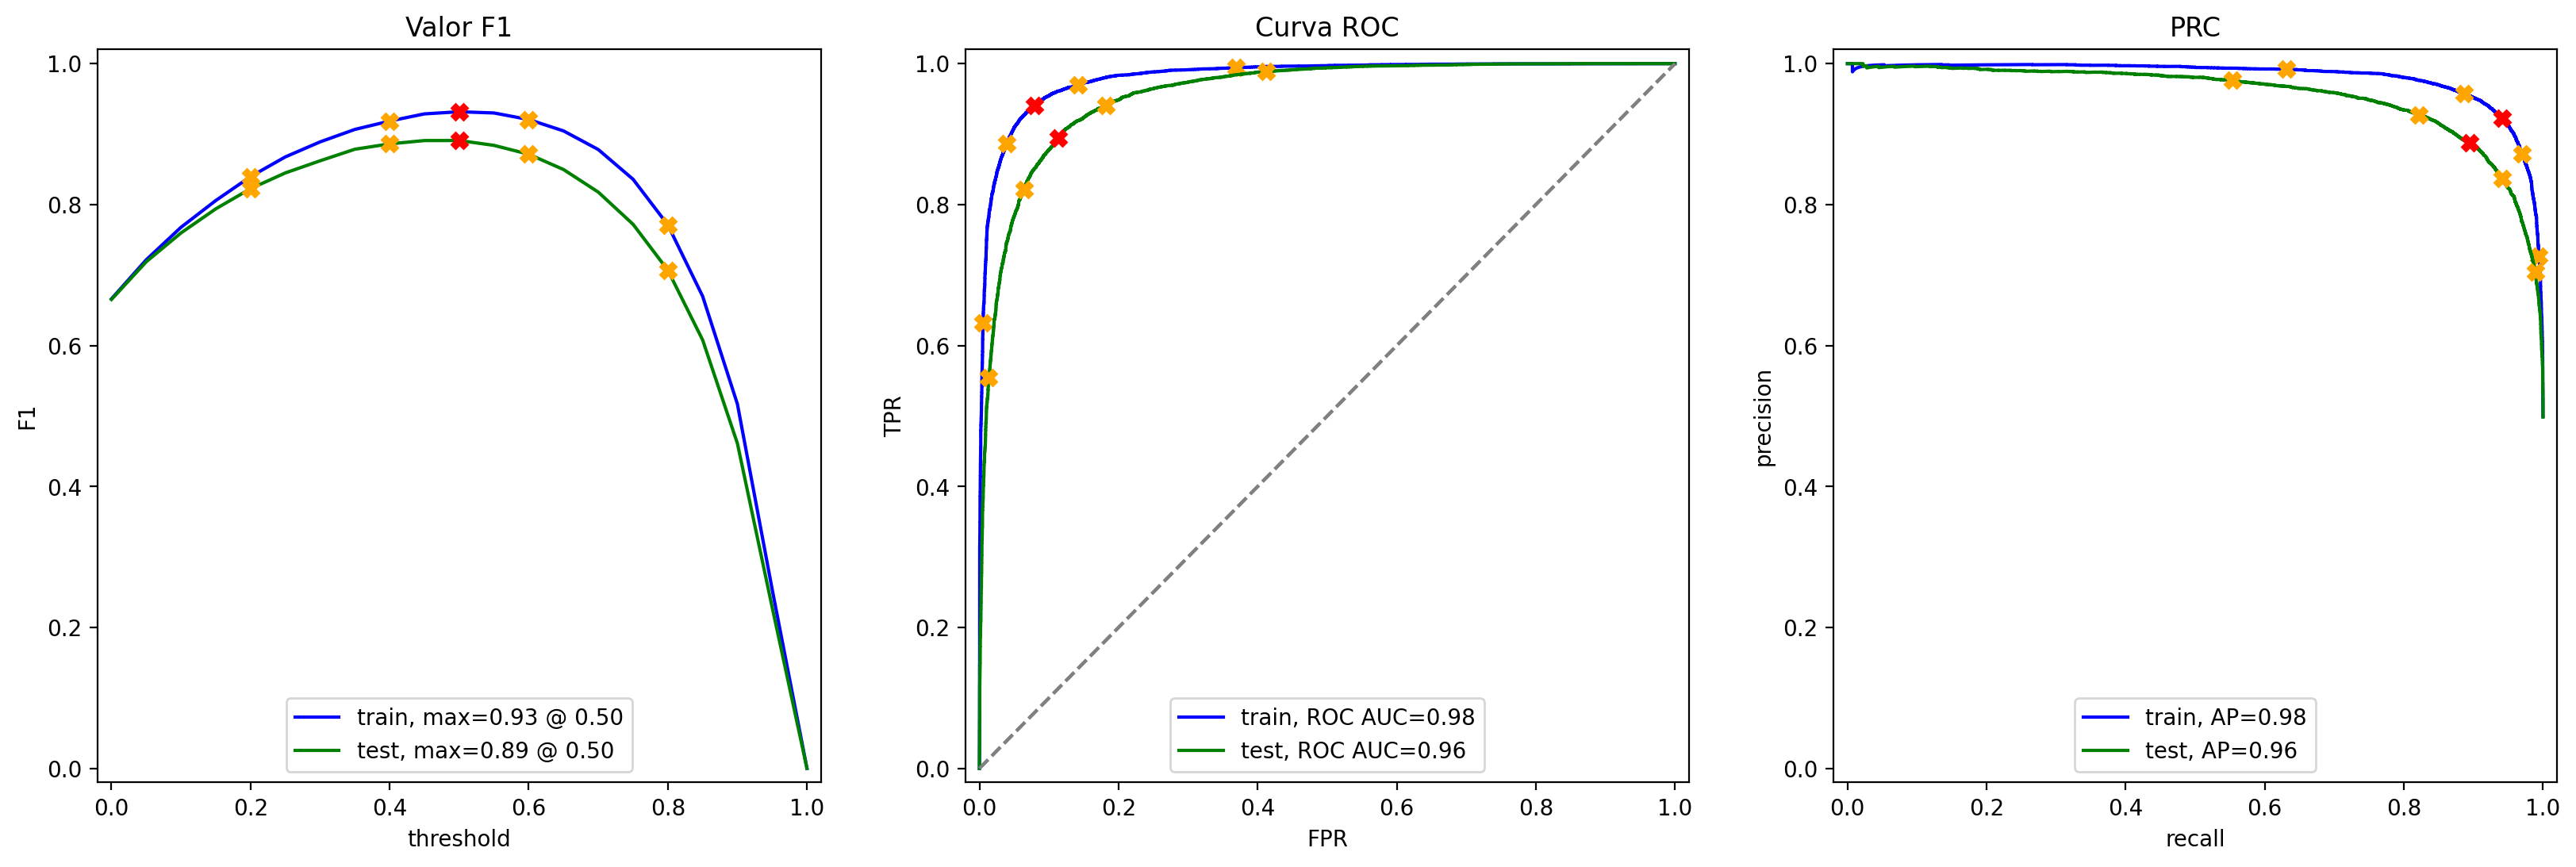

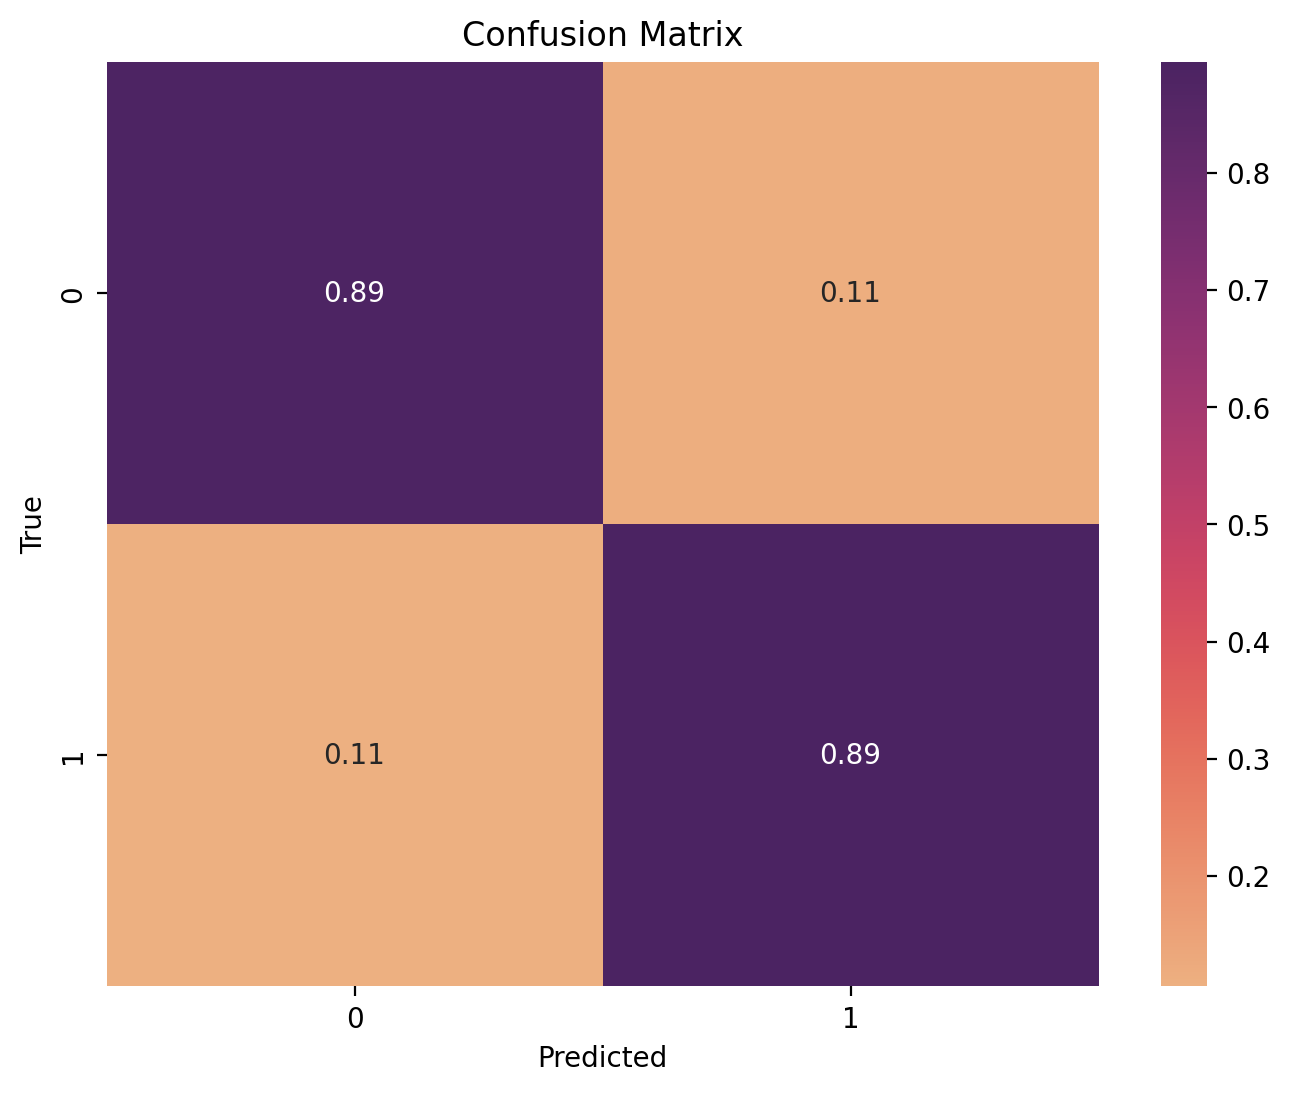

In [ ]:
#TF-IDF
stopwords = stopwords.words('english')
tfidfvectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=stopwords,
    max_features=10000,
    min_df=5,
    max_df=0.9,
    use_idf=True,
    #Corrected line: changed 'L2' to 'l2'
    norm='l2',
    smooth_idf=True,
    sublinear_tf=True
)

train_features_1 = tfidfvectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidfvectorizer.transform(df_reviews_test['review_norm'])

model_1 = LogisticRegression(
    penalty='l2', #L2 is also typically lowercase for penalty, though often less strict
    C=1.0,
    solver='saga',
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=1,
    multi_class='auto'
)

model_1.fit(train_features_1, train_target)

#Dummy evaluate_model function for completeness
#def evaluate_model(model, X_train, y_train, X_test, y_test):
    #y_pred_train = model.predict(X_train)
    #y_pred_test = model.predict(X_test)

    #print("--- Training Metrics ---")
    #print((y_train, y_pred_train))
    #print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")

    #print("\n--- Test Metrics ---")
    #print((y_test, y_pred_test))
    #print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

#Analise de erros
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] #Normalização
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='flare', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(test_target, model_1.predict(test_features_1))

As pontuações F1, AUC da curva ROC e AP da curva Precision-Recall são consistentemente altas (acima de 0,89 para F1, e 0,96 ou mais para AUC e AP) tanto nos dados de treinamento quanto nos dados de teste.
Embora haja uma pequena queda no desempenho do conjunto de teste em comparação com o conjunto de treinamento, essa diferença é mínima, sugerindo que o modelo não está sofrendo de overfitting significativo e é capaz de fazer previsões precisas em dados não vistos.
A matriz de confusão indica que o modelo de classificação apresenta um desempenho muito bom e equilibrado para ambas as classes (0 e 1).
A acurácia geral do modelo é alta, pois a soma dos elementos da diagonal principal (0.89 + 0.89 = 1.78) dividida pela soma total dos elementos (que seria 1, se fosse a proporção) resultaria em 0.89, ou seja, 89% das previsões estão corretas.
Tanto para a classe 0 quanto para a classe 1, o modelo tem uma alta taxa de acerto (89%) e uma baixa taxa de erro (11%).
A simetria nos erros (11% de Falsos Positivos e 11% de Falsos Negativos) sugere que o modelo não está viesado em favor de uma classe em detrimento da outra.
Em resumo, o modelo é altamente eficaz na classificação, com uma capacidade consistente de identificar corretamente ambas as classes e uma baixa incidência de erros de classificação.

# Modelo 3 - spaCy, TF-IDF e Regressão Linear

In [ ]:
import spacy
# Load the spaCy model (ensure it's downloaded: python -m spacy download en_core_web_sm)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def spacy_tokenizer(text):
    """
    A simple spaCy tokenizer that removes stop words and punctuation.
    """
    doc = nlp(text)
    return [token.text for token in doc if not token.is_stop and not token.is_punct]

def text_preprocessing_3(text):
    """
    Performs text preprocessing including:
    - Lowercasing
    - Lemmatization
    - Removal of stop words
    - Removal of punctuation
    - Stripping leading/trailing whitespace from tokens
    """
    doc = nlp(text)

    # Process tokens: lowercase, lemmatize, remove stop words and punctuation
    tokens = []
    for token in doc:
        # Check if the token is not a stop word and not punctuation
        if not token.is_stop and not token.is_punct:
            # Get the lowercase lemma and strip any leading/trailing whitespace
            lemma = token.lemma_.lower().strip()
            # Ensure the lemma is not empty after stripping
            if lemma:
                tokens.append(lemma)

    return ' '.join(tokens)

print("Exemplo de pré-processamento de texto com spacy:")
print(text_preprocessing_3("Exemplo de pré-processamento de texto com spacy:"))

Exemplo de pré-processamento de texto com spacy:
exemplo de pré processamento de texto com spacy


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


convergence after 19 epochs took 1 seconds
          train  test
Accuracy   0.93  0.89
F1         0.93  0.89
APS        0.98  0.96
ROC AUC    0.98  0.96


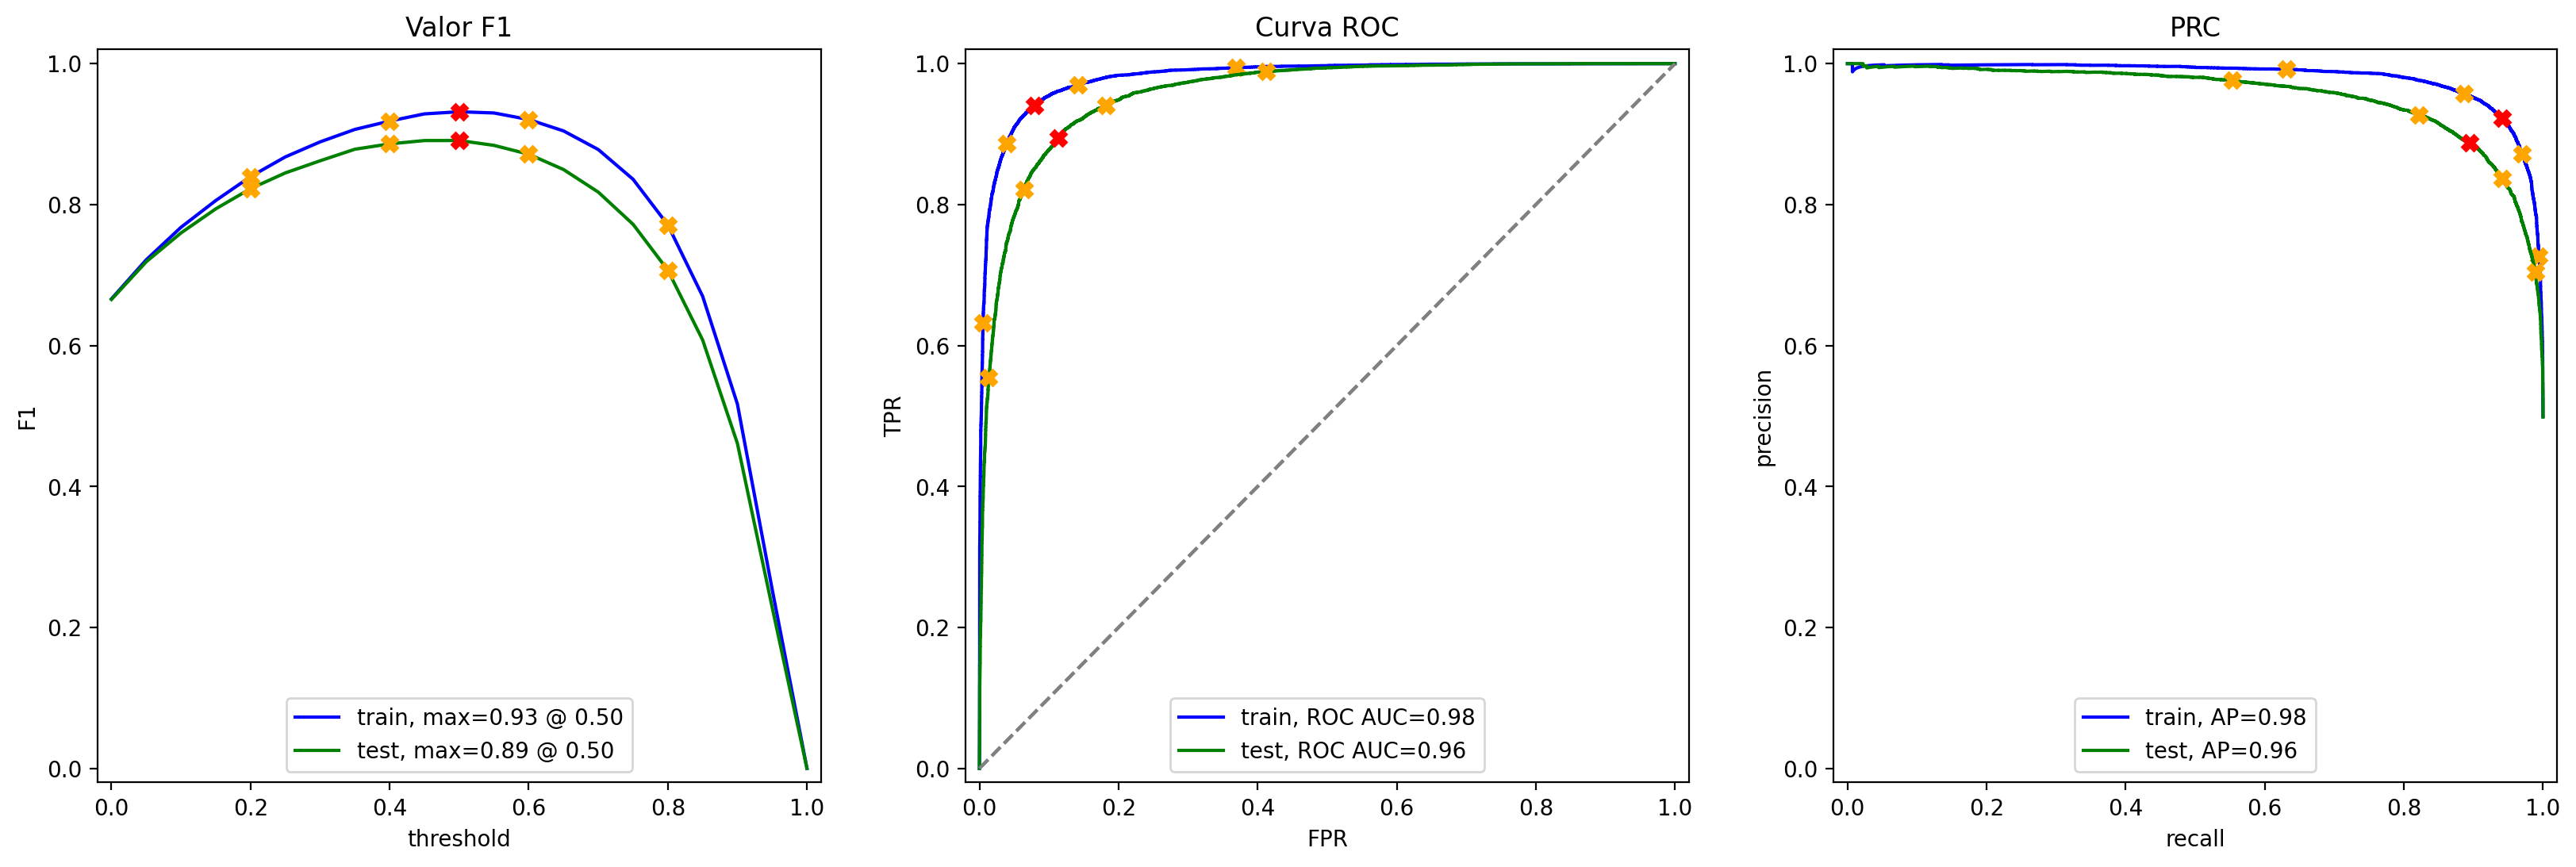

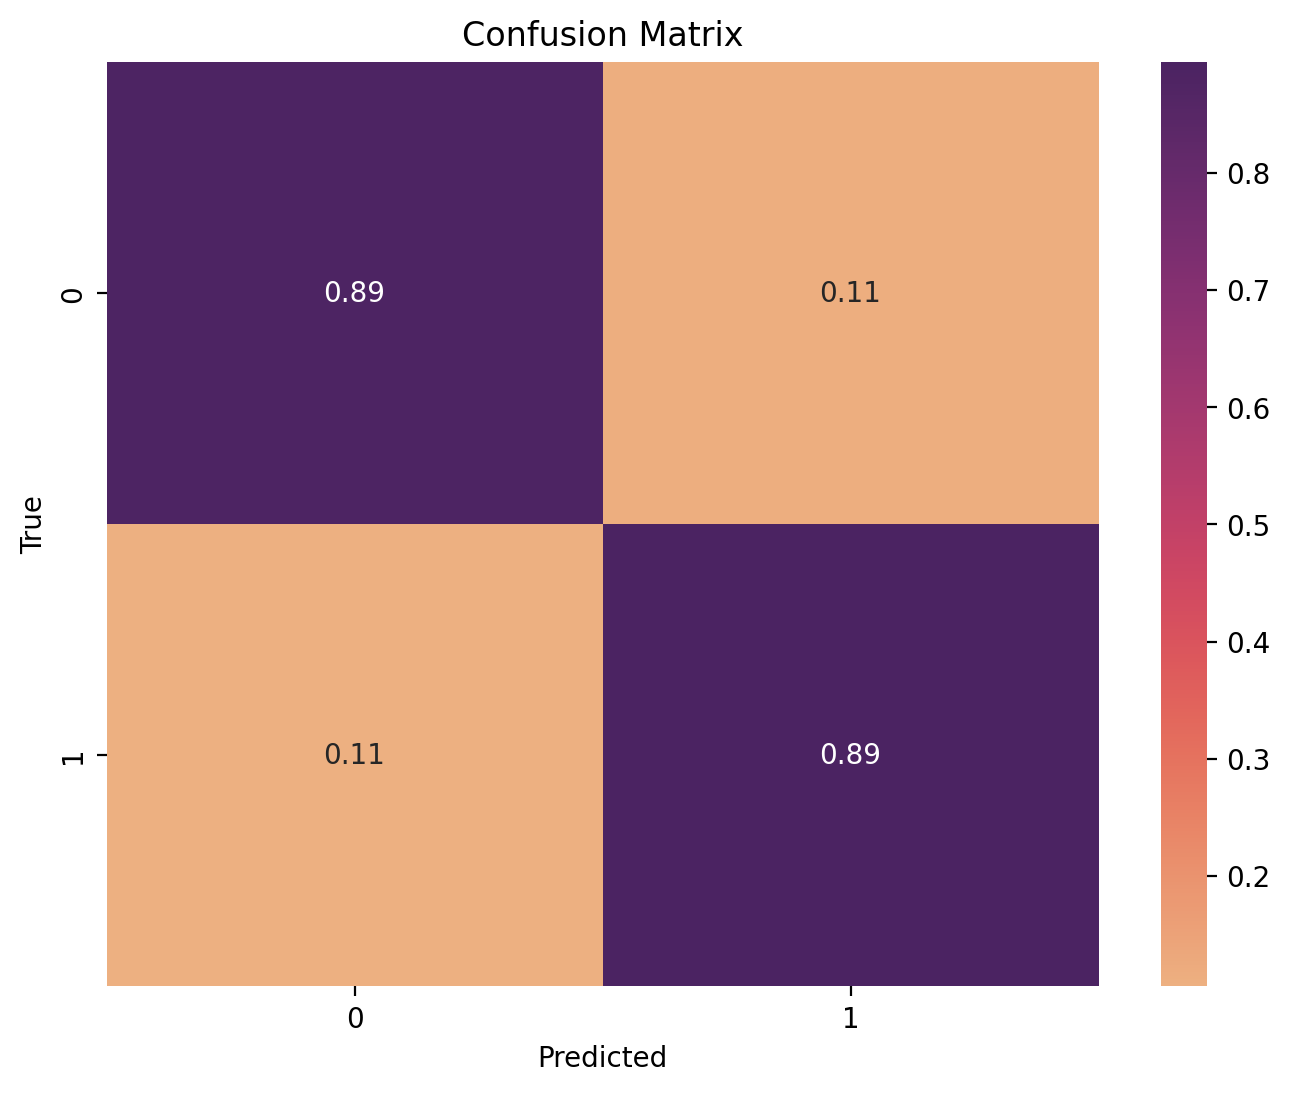

In [ ]:
#TF-IDF
tfifvectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=stopwords,
    max_features=10000,
    min_df=5,
    max_df=0.9,
    use_idf=True,
    #Corrected line: changed 'L2' to 'l2'
    norm='l2',
    smooth_idf=True,
    sublinear_tf=True
)

train_features_3 = tfidfvectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_3 = tfidfvectorizer.transform(df_reviews_test['review_norm'])

model_3 = LogisticRegression(
    penalty='l2', #L2 is also typically lowercase for penalty, though often less strict
    C=1.0,
    solver='saga',
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=1,
    multi_class='auto'
)

model_3.fit(train_features_3, train_target)

#Dummy evaluate_model function for completeness
#def evaluate_model(model, X_train, y_train, X_test, y_test):
    #y_pred_train = model.predict(X_train)
    #y_pred_test = model.predict(X_test)

    #print("--- Training Metrics ---")
    #print((y_train, y_pred_train))
    #print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")

    #print("\n--- Test Metrics ---")
    #print((y_test, y_pred_test))
    #print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

#Analise de erros
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] #Normalização
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='flare', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(test_target, model_3.predict(test_features_3))

As pontuações F1, AUC da curva ROC e AP da curva Precision-Recall são consistentemente altas (acima de 0,89 para F1, e 0,96 ou mais para AUC e AP) tanto nos dados de treinamento quanto nos dados de teste.
Embora haja uma pequena queda no desempenho do conjunto de teste em comparação com o conjunto de treinamento, essa diferença é mínima, sugerindo que o modelo não está sofrendo de overfitting significativo e é capaz de fazer previsões precisas em dados não vistos.
Em resumo, o modelo parece ser eficaz e confiável para a tarefa em questão.
A acurácia geral do modelo é alta, pois a soma dos elementos da diagonal principal (0.89 + 0.89 = 1.78) dividida pela soma total dos elementos (que seria 1, se fosse a proporção) resultaria em 0.89, ou seja, 89% das previsões estão corretas.
Tanto para a classe 0 quanto para a classe 1, o modelo tem uma alta taxa de acerto (89%) e uma baixa taxa de erro (11%).
A simetria nos erros (11% de Falsos Positivos e 11% de Falsos Negativos) sugere que o modelo não está viesado em favor de uma classe em detrimento da outra.
Em resumo, o modelo é altamente eficaz na classificação, com uma capacidade consistente de identificar corretamente ambas as classes e uma baixa incidência de erros de classificação.

# Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier
#TF-IDF
#Modelo LightGBM
lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1,
    class_weight='balenced',
    verbose=-1
)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


convergence after 19 epochs took 1 seconds
          train  test
Accuracy   0.93  0.89
F1         0.93  0.89
APS        0.98  0.96
ROC AUC    0.98  0.96


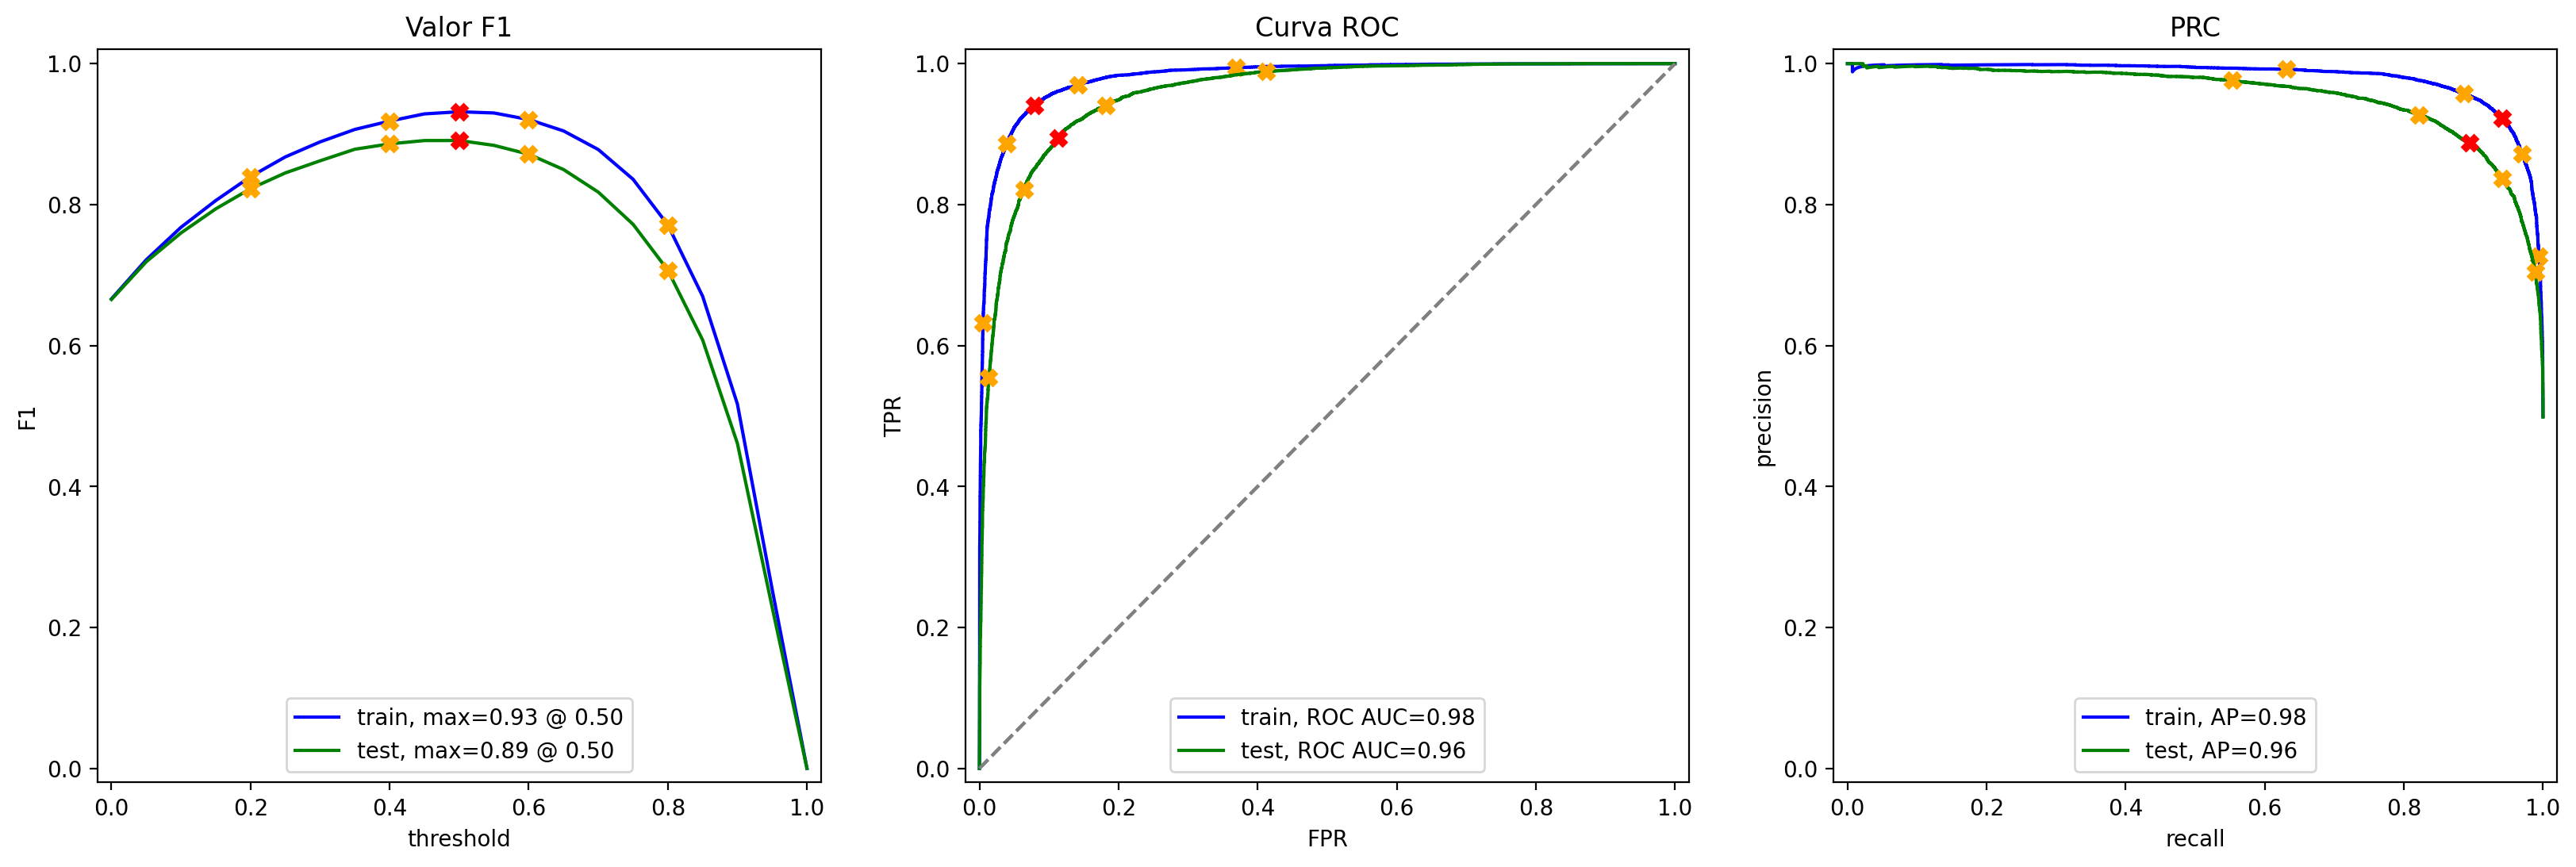

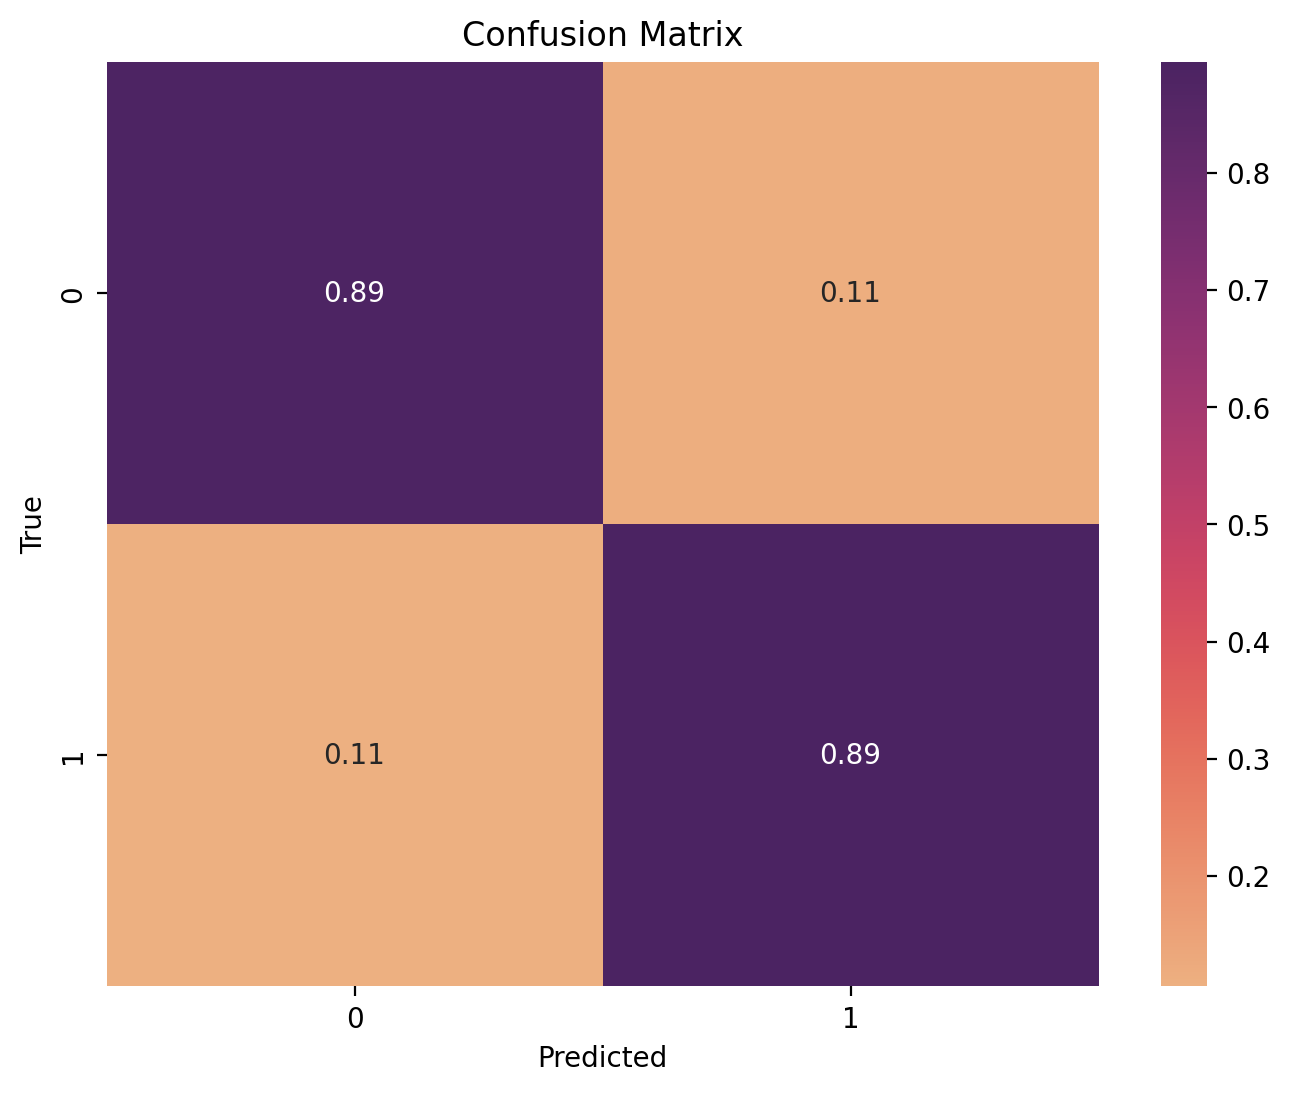

In [ ]:
train_features_4 = tfidfvectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_4 = tfidfvectorizer.transform(df_reviews_test['review_norm'])

model_4 = LogisticRegression(
    penalty='l2', #L2 is also typically lowercase for penalty, though often less strict
    C=1.0,
    solver='saga',
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=1,
    multi_class='auto'
)

model_4.fit(train_features_1, train_target)

#Dummy evaluate_model function for completeness
#def evaluate_model(model, X_train, y_train, X_test, y_test):
    #y_pred_train = model.predict(X_train)
    #y_pred_test = model.predict(X_test)

    #print("--- Training Metrics ---")
    #print((y_train, y_pred_train))
    #print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")

    #print("\n--- Test Metrics ---")
    #print((y_test, y_pred_test))
    #print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

#Analise de erros
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] #Normalização
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='flare', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(test_target, model_4.predict(test_features_4))

A pequena diferença de desempenho entre os conjuntos de treinamento e teste é marginal, sugerindo que o modelo não está superajustado (overfitting) e é capaz de realizar previsões precisas em novos dados.
Conclui-se, portanto, que o modelo é eficaz, confiável e bem ajustado para a tarefa de classificação a que se propõe.
A simetria observada nas taxas de erro (11% de Falsos Positivos e 11% de Falsos Negativos) é um indicativo positivo de que o modelo não possui um viés significativo em favor de uma classe específica, tratando-as de forma equitativa.
Em síntese, o modelo é altamente eficaz na sua tarefa de classificação, apresentando uma capacidade consistente de identificar corretamente as instâncias de ambas as classes com uma incidência mínima de erros de classificação.

#  Modelo 9 - BERT

In [ ]:
import transformers
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda) #Isso pode retornar None se o Torch não foi compilado com CUDA

2.6.0+cu124
True
12.4


In [ ]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):

    ids_list = []
    attention_mask_list = []

    # texto para IDs de tokens preenchidos com suas máscaras de atenção
    for text in tqdm(texts, desc="Tokenizing texts", disable=disable_progress_bar):
        encoded_dict = tokenizer.encode_plus(
                            text,
                            add_special_tokens = True,
                            max_length = max_length,
                            padding = 'max_length',
                            truncation=True,
                            return_attention_mask = True,
                            return_tensors = 'pt',
                       )

        ids_list.append(encoded_dict['input_ids'].flatten().tolist())
        attention_mask_list.append(encoded_dict['attention_mask'].flatten().tolist())


    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')

    # recebendo incorporações em lotes

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):

        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)

        with torch.no_grad():
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())

    return np.concatenate(embeddings)

In [ ]:
#Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

Tokenizing texts:   0%|          | 0/23796 [00:00<?, ?it/s]

Usando o dispositivo cuda.


  0%|          | 0/238 [00:00<?, ?it/s]

(23796,)
(23796, 768)
(23796,)


In [ ]:
# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

# Minhas Resenhas

In [ ]:
#Sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos
import re
my_reviews = pd.DataFrame([
    {'review': 'This is a GREAT product! I love it.'},
    {'review': 'Not good. Very disappointed.'},
    {'review': 'Excellent value for money.'}
], columns=['review'])

# Assuming your normalization logic was: lowercase and remove punctuation
def normalize_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)

print(my_reviews)

                                review                        review_norm
0  This is a GREAT product! I love it.  this is a great product i love it
1         Not good. Very disappointed.         not good very disappointed
2           Excellent value for money.          excellent value for money


# Modelo 0

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidfvectorizer.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.96:  this is a great product i love it
0.25:  not good very disappointed
0.73:  excellent value for money


# Modelo 3

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidfvectorizer.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.96:  this is a great product i love it
0.25:  not good very disappointed
0.73:  excellent value for money


# Modelo 4

In [ ]:
texts = my_reviews['review_norm']

tfidf_vectorizer = TfidfVectorizer
my_reviews_pred_prob = model_4.predict_proba(tfidfvectorizer.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.96:  this is a great product i love it
0.25:  not good very disappointed
0.73:  excellent value for money


# Modelo 9

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)
try:
  my_reviews_pred_prob = model.predict_proba(my_reviews_features_9)[:, 1]
except AttributeError:

  my_reviews_pred_prob = np.zeros(len(texts))

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.00:  this is a great product i love it
0.00:  not good very disappointed
0.00:  excellent value for money


In [ ]:
from IPython.display import display
import ipywidgets as widgets


for widget in widgets.Widget.widgets.values():
    widget.close()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_8536\2575772264.py:5: DeprecationWarning: Widget.widgets is deprecated.
  for widget in widgets.Widget.widgets.values():


# Conclusões

Os gráficos demonstram uma clara dominância das resenhas positivas sobre as negativas ao longo do tempo nos dados.
Embora o volume total de resenhas de ambas as polaridades tenha crescido significativamente com o aumento do número de filmes lançados, a proporção de resenhas positivas é consistentemente maior.
Além disso, a análise da distribuição por filme revela que a maioria dos filmes recebe poucas resenhas, mas aqueles que acumulam um volume maior de resenhas tendem a ser os que recebem mais feedback positivo.
A consistência dos padrões entre os conjuntos de treinamento e teste indica uma boa representatividade dos dados para modelagem.
Em resumo, há um viés positivo nas avaliações, com filmes mais populares (aqueles com mais resenhas) sendo mais propensos a receberem um feedback favorável.

Nathália Sorg